In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.image as img
import pandas as pd
import os
from pathlib import Path
import read_sim_not_clin_bg as rsnb
from scipy.optimize import curve_fit

### Для просмотра файлов в папке

In [2]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021' # второй телескоп
folder_path = '/media/alexandra/DATA/IACT01_2020-2021' # первый телескоп

# Cписок файлов в папке
file_names = os.listdir(folder_path)

# Выводим названия файлов
for file_name in file_names:
    # print(file_name)
    break

### Считываем файлы в таблицу

In [3]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021'
folder_path = '/media/alexandra/DATA/IACT01_2020-2021'
df_19 = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') # 19-год (один день)

# Cписок всех CSV-файлов в папке
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

# Читаем каждый файл и объединяем их в один DataFrame
dataframes = [pd.read_csv(file) for file in file_paths]
hillas = pd.concat(dataframes, ignore_index=True)
combined_hillas = pd.concat([df_19, hillas], ignore_index=True)

hillas

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49


### Применяем каты

In [4]:
def filter_hillas_data(df):
    # Common filters for both source and anti-source
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    
    # Source selection (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source'  # Add identifier column
    
    # Anti-source selection (dist2)
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'  # Add identifier column
    
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas)
source_events

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,source_type
1052,1,8265,13:38:25:178:574:640,1612791505178574640,0.18,0.03,182.33163,60.149,184.85313,60.155,...,22.01,1.28,-0.01,1,1,0,0,9.12,0.93,source
1697,1,13435,13:39:06:036:027:050,1612791546036027050,0.04,0.03,182.64775,60.149,185.17154,60.146,...,22.01,1.28,-0.00,1,1,0,0,9.27,0.93,source
1916,1,15163,13:39:19:800:552:970,1612791559800552970,0.20,0.03,182.75627,60.149,185.28023,60.143,...,22.01,1.28,0.00,1,1,0,0,9.27,0.93,source
1928,1,15236,13:39:20:447:435:430,1612791560447435430,0.05,0.03,182.76044,60.149,185.28411,60.142,...,22.01,1.28,0.00,1,1,0,0,9.27,0.93,source
2930,2,39794,13:40:35:333:406:490,1612791635333406490,0.17,0.03,188.13838,59.912,185.86602,60.124,...,22.01,-1.15,-0.25,0,0,0,0,-1.00,0.91,source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295686,66,878763,16:21:50:055:013:780,1612628510055013780,0.06,0.03,244.35383,45.579,243.04193,46.349,...,22.01,-0.92,-0.80,1,1,0,0,9.09,0.50,source
3295812,66,879616,16:22:02:057:862:990,1612628522057862990,0.06,0.03,244.40773,45.551,243.09604,46.321,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.50,source
3296083,66,881340,16:22:26:047:641:830,1612628546047641830,0.05,0.03,244.51569,45.495,243.20413,46.266,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.49,source
3296364,67,883301,16:23:04:508:479:340,1612628584508479340,0.01,0.03,244.68243,45.404,243.37718,46.177,...,22.01,-0.92,-0.80,1,1,0,0,9.08,0.49,source


### Гистограмма по тета

/tmp/ipykernel_42605/1508846047.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
/tmp/ipykernel_42605/1508846047.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 -


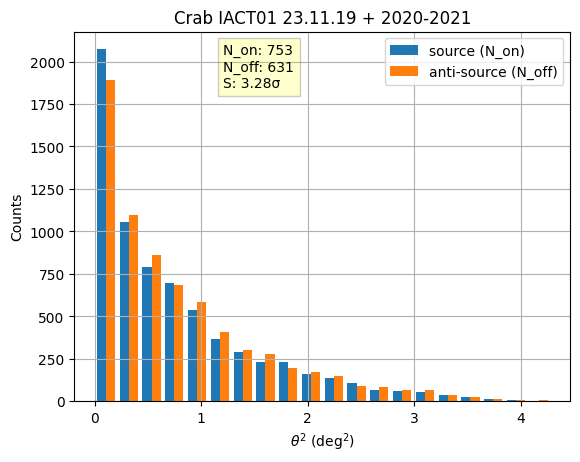

N_on = 753, N_off = 631, Significance = 3.28σ


In [5]:
def calculate_ksi(rc, size):
    if rc < 7.5:
        return 1.3
    elif 7.5 < rc < 10:
        return 1.6
    elif rc > 10:
        if size < 700:
            return 2.0
        elif 700 < size < 1000:
            return 1.9
        elif 1000 < size < 1250:
            return 1.75
        elif 1250 < size < 1500:
            return 1.5
    return np.nan

# Process source events (N_on)
source_events['rc'] = source_events['dist1'] / 0.1206
source_events['ksi'] = source_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
source_events = source_events[~source_events['ksi'].isna()]  # Remove NaN values
source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 - 
                          2 * source_events['disp'] * source_events['dist1'] * np.cos(np.radians(source_events['alpha1'])))

# Process anti-source events (N_off)
antisource_events['rc'] = antisource_events['dist2'] / 0.1206
antisource_events['ksi'] = antisource_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
antisource_events = antisource_events[~antisource_events['ksi'].isna()]  # Remove NaN values
antisource_events['disp'] = antisource_events['ksi'] * (1.0 - antisource_events['width'] / antisource_events['length'])
antisource_events['theta2'] = (antisource_events['disp']**2 + antisource_events['dist2']**2 - 
                              2 * antisource_events['disp'] * antisource_events['dist2'] * np.cos(np.radians(antisource_events['alpha2'])))

# Create histogram
plt.hist([source_events['theta2'], antisource_events['theta2']], 
         bins=20, label=['source (N_on)', 'anti-source (N_off)'])
plt.legend(loc='upper right')
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Counts')
plt.title('Crab IACT01 23.11.19 + 2020-2021')

# Calculate statistics (using θ² < 0.05 cut)
theta_cut = 0.05
N_on = len(source_events[source_events['theta2'] < theta_cut])
N_off = len(antisource_events[antisource_events['theta2'] < theta_cut])

# Calculate significance
S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
             fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
             xy=(0.3, 0.85), xycoords='axes fraction')

plt.grid()
plt.savefig('teta_1bg_231119_and_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')
# print(antisource_events);

### Гистограмма по alpha

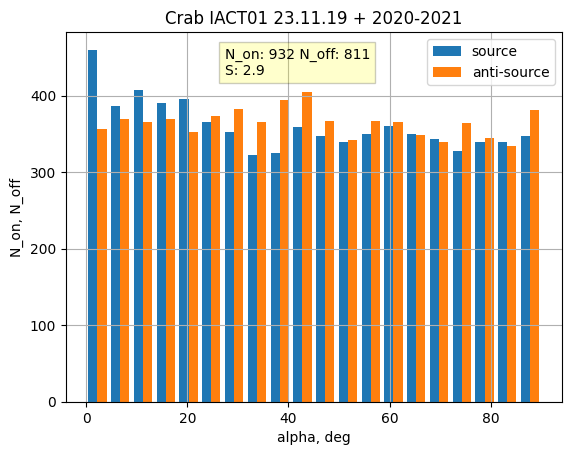

N_on = 932 N_off = 811 S_lima = 2.9


In [6]:
# та же самая функция, что выше только с доп катами, как у Паши В
# def filter_hillas_data(df):
#     common_filters = (
#         (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
#         (df['delta_time'] < 0.5) &
#         (df['error_deg'] < 0.1) &
#         (df['size'] > 120) &
#         (df['width'] > 0.024) &
#         (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
#         (df['length'] < 0.145 * np.log10(df['size']))
#     )
#     source_df = df[
#         common_filters &
#         (df['dist1'].between(0.36, 1.44))
#     ].copy()
#     source_df['source_type'] = 'source' 
    
#     anti_source_df = df[
#         common_filters &
#         (df['dist2'].between(0.36, 1.44))
#     ].copy()
#     anti_source_df['source_type'] = 'anti-source'
#     return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(combined_hillas)

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=20,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
plt.title('Crab IACT01 23.11.19 + 2020-2021') 
N_on = len(source_events.loc[source_events['alpha1']<10])
N_off = len(antisource_events.loc[antisource_events['alpha2']<10])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.savefig('alpha_231119_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)

N_on = 431.0 N_off = 342.0 3.2011075056319482 3.2


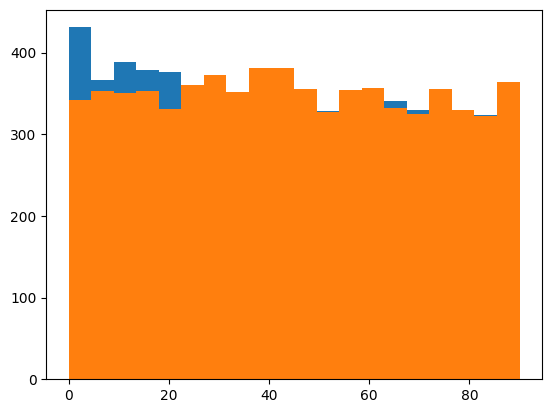

In [7]:
# Пашин В. вариант по альфа
# table_had = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') #23.11.19
table_had = hillas

on10 = plt.hist(table_had['alpha1'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist1'] > 0.36) & 
                      (table_had['dist1'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
off10 = plt.hist(table_had['alpha2'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist2'] > 0.36) & 
                      (table_had['dist2'] < 1.44) & 
                      (table_had['width'] > 0.024) & 

                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
N_on = on10[0]
N_off = off10[0]
S_lima = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
print('N_on =', on10[0], 'N_off =', off10[0], (on10[0] - off10[0])/np.sqrt(on10[0] + off10[0]), S_lima)

### Пересчитываем параметры для 5 точек фона

In [5]:
# Пересчитываем альфа и дисты
def add_background_alphas_dists_thetas_abs(df):
    df = df.copy()

    # Вектор от CoG до источника
    dx = df['source_x'] - df['Xc']
    dy = df['source_y'] - df['Yc']
    v_angle = np.arctan2(dy, dx)  # угол в радианах

    # Направление главной оси эллипса: от вектора на источник - alpha1
    u_angle = np.arctan(df.a_axis)  # главная ось в радианах
    u_x = np.cos(u_angle)
    u_y = np.sin(u_angle)

    # Расстояние от центра камеры до источника — радиус окружности
    r = np.sqrt(df['source_x']**2 + df['source_y']**2)

    # Угол на источник из центра камеры
    angle0 = np.arctan2(df['source_y'], df['source_x'])

    angles_deg = [180, 60, 120, 240, 300] # антиисточник и 4 новых фоновых
    angles_rad = [angle0 + np.deg2rad(a) for a in angles_deg]

    for i, angle in enumerate(angles_rad, start=1):
        # Координаты точки на окружности
        x = r * np.cos(angle)
        y = r * np.sin(angle)

        dx = x - df['Xc']
        dy = y - df['Yc']
        dist = np.sqrt(dx**2 + dy**2)

        v_angle = np.arctan2(dy, dx)
        delta = np.abs(v_angle - u_angle)
        delta = np.mod(delta, 2 * np.pi)
        alpha = np.minimum(delta, 2 * np.pi - delta)
        alpha_deg = np.rad2deg(alpha)
        alpha_deg = np.where(alpha_deg > 90, 180 - alpha_deg, alpha_deg)

        df[f'bg{i}_dist'] = dist
        df[f'bg{i}_alpha'] = alpha_deg
    return df

hillas_with_5point_background = add_background_alphas_dists_thetas_abs(hillas)

hillas_with_5point_background

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,3.267376,76.689544,2.444815,33.964588,3.261311,54.073946,2.460959,83.117154,1.182071,81.203166
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,1.566778,82.321326,1.968928,20.937865,2.019879,58.349482,0.791484,27.883935,0.650548,82.987526
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,4.654966,79.917609,2.459209,74.694962,3.693295,68.221081,4.701519,84.364891,3.809405,71.910381
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,2.418068,82.522523,4.168380,57.765204,3.637146,74.968653,1.616118,53.285497,2.599693,30.226275
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,3.888517,58.976695,1.700245,51.002153,2.767081,69.776831,4.221194,41.426104,3.612835,24.842567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,3.485078,58.483270,1.450223,70.164926,2.410112,47.739968,3.844140,76.550069,3.327449,85.957370
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,2.701440,86.954482,4.188162,67.928467,3.803544,84.365523,1.789515,72.442452,2.505218,46.003744
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,2.344840,49.168170,2.661074,82.089323,1.690138,78.576713,3.516351,54.727350,4.073018,70.947139
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,2.674621,38.636349,3.555579,74.335359,3.518057,54.742070,1.481852,43.393132,1.568853,89.780892


### Рисуем выбранные точки

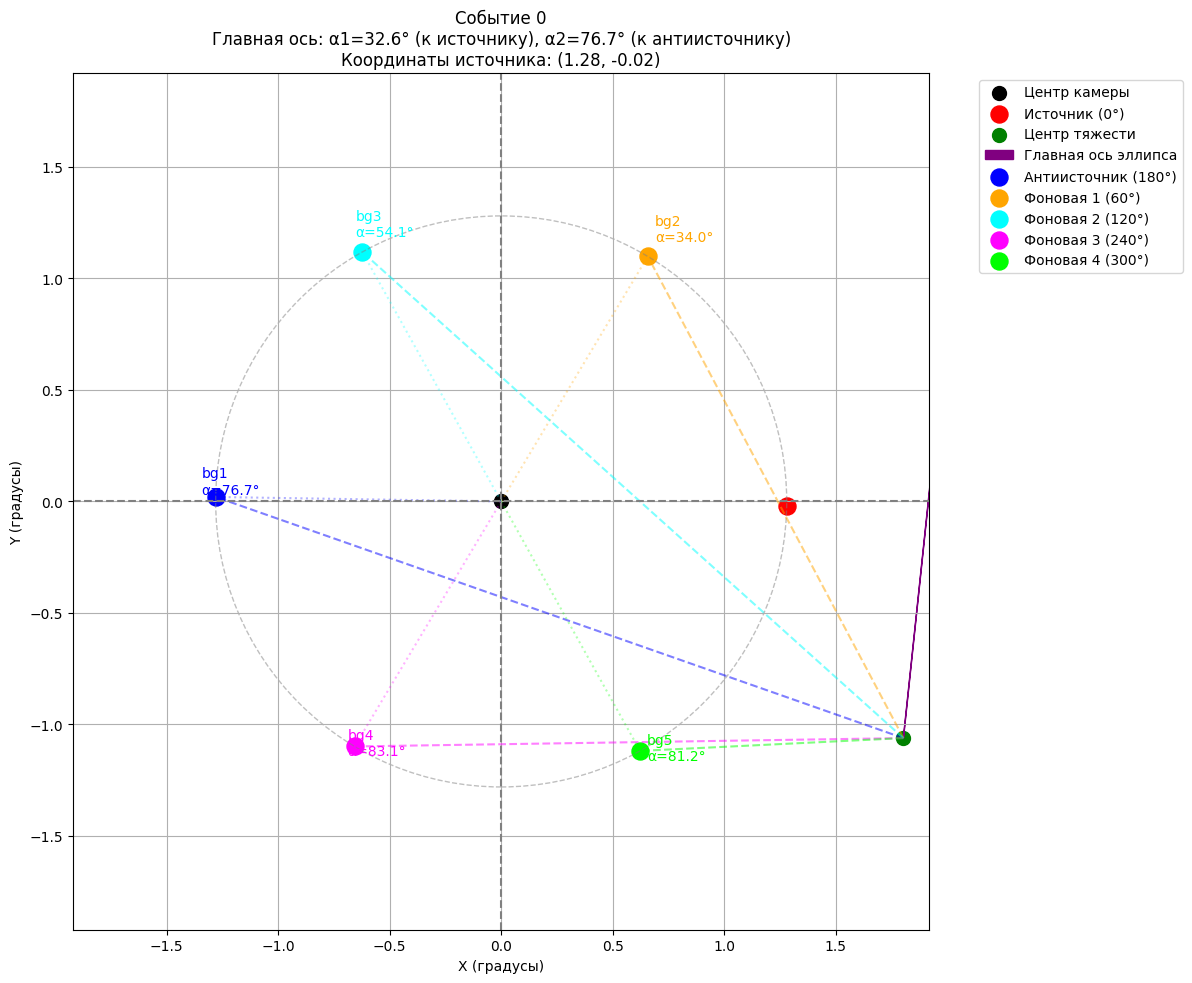

In [6]:
def visualize_5_background_points(df, event_index=0):
    """Визуализация 5 фоновых точек для конкретного события"""
    event = df.iloc[event_index]
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Центр камеры
    ax.scatter(0, 0, color='black', s=100, label='Центр камеры')
    
    # Координаты источника (0°)
    ax.scatter(event['source_x'], event['source_y'], color='red', s=150, label='Источник (0°)')
    
    # Центр тяжести события (CoG)
    ax.scatter(event['Xc'], event['Yc'], color='green', s=100, label='Центр тяжести')
    
    # Главная ось эллипса
    axis_length = 2.0
    angle_rad = np.arctan(event['a_axis'])
    dx = axis_length * np.cos(angle_rad)
    dy = axis_length * np.sin(angle_rad)
    ax.arrow(event['Xc'], event['Yc'], dx, dy, 
             head_width=0.1, head_length=0.2, fc='purple', ec='purple', 
             label='Главная ось эллипса')

    # Углы для фоновых точек [0, 180, 60, 120, 240, 300] - 0° это источник
    angles_deg = [180, 60, 120, 240, 300]  # 5 фоновых точек
    bg_colors = ['blue', 'orange', 'cyan', 'magenta', 'lime']
    bg_labels = ['Антиисточник (180°)', 'Фоновая 1 (60°)', 
                 'Фоновая 2 (120°)', 'Фоновая 3 (240°)', 
                 'Фоновая 4 (300°)']
    
    # Радиус окружности (расстояние от центра до источника)
    r = np.sqrt(event['source_x']**2 + event['source_y']**2)
    
    # Угол источника
    angle0 = np.arctan2(event['source_y'], event['source_x'])
    
    for i, (angle_deg, color, label) in enumerate(zip(angles_deg, bg_colors, bg_labels), start=1):
        angle_rad = angle0 + np.deg2rad(angle_deg)
        
        # Координаты фоновой точки
        bg_x = r * np.cos(angle_rad)
        bg_y = r * np.sin(angle_rad)
        
        # Линия от центра камеры к точке
        ax.plot([0, bg_x], [0, bg_y], color=color, linestyle=':', alpha=0.3)
        
        # Фоновая точка
        ax.scatter(bg_x, bg_y, color=color, s=150, label=label)
        
        # Линия от CoG к фоновой точке
        ax.plot([event['Xc'], bg_x], [event['Yc'], bg_y], 
                color=color, linestyle='--', alpha=0.5)
        
        # Подпись точки
        ax.text(bg_x*1.05, bg_y*1.05, f'bg{i}\nα={event[f"bg{i}_alpha"]:.1f}°', 
                color=color, ha='left', va='bottom')

    # Окружность через источник
    circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', alpha=0.5)
    ax.add_patch(circle)
    
    # Настройки графика
    ax.set_xlim(-r*1.5, r*1.5)
    ax.set_ylim(-r*1.5, r*1.5)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlabel('X (градусы)')
    ax.set_ylabel('Y (градусы)')
    
    title = (f"Событие {event_index}\n"
             f"Главная ось: α1={event['alpha1']:.1f}° (к источнику), "
             f"α2={event['alpha2']:.1f}° (к антиисточнику)\n"
             f"Координаты источника: ({event['source_x']:.2f}, {event['source_y']:.2f})")
    ax.set_title(title)
    
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

visualize_5_background_points(hillas_with_5point_background, 0)

### Накладываем каты

In [7]:
def filter_hillas_data_split_background(df):
    # Общие фильтры
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    # Таблица с источником (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ]
    # Отдельные таблицы для каждого фонового региона
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ]
    bg2_df = df[
        common_filters &
        (df['bg2_dist'].between(0.36, 1.44))
    ]
    bg3_df = df[
        common_filters &
        (df['bg3_dist'].between(0.36, 1.44))
    ]
    bg4_df = df[
        common_filters &
        (df['bg4_dist'].between(0.36, 1.44))
    ]
    bg5_df = df[
        common_filters &
        (df['bg5_dist'].between(0.36, 1.44))
    ]
    return source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df

source, anti_source, bg2, bg3, bg4, bg5 = filter_hillas_data_split_background(hillas_with_5point_background)
bg2

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
552,1,4483,13:37:56:139:573:630,1612791476139573630,0.14,0.03,182.10608,60.151,184.62782,60.161,...,0.813455,80.157091,1.405725,85.314762,0.747653,29.932343,1.476994,39.932480,1.896994,2.414158
593,1,4815,13:37:58:527:255:980,1612791478527255980,0.03,0.03,182.12550,60.151,184.64724,60.161,...,1.392429,84.024882,0.979665,41.694201,0.315742,21.087630,2.153618,61.402937,2.344808,28.689683
1052,1,8265,13:38:25:178:574:640,1612791505178574640,0.18,0.03,182.33163,60.149,184.85313,60.155,...,3.076028,24.422616,1.106615,56.461208,2.359362,47.128098,3.002551,0.148598,2.161787,21.689828
1916,1,15163,13:39:19:800:552:970,1612791559800552970,0.20,0.03,182.75627,60.149,185.28023,60.143,...,2.273750,54.738445,0.679562,21.854510,1.692470,20.942663,2.252281,87.589866,1.634051,58.440902
2200,2,17676,13:39:50:487:076:100,1612791590487076100,0.01,0.03,182.99998,60.133,185.51694,60.135,...,3.030535,41.076089,0.818212,46.366651,1.993879,23.505098,3.329662,63.670947,2.789367,85.621485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295766,66,879280,16:21:57:362:313:800,1612628517362313800,0.14,0.03,244.38746,45.561,243.07575,46.331,...,1.454290,48.804910,0.795641,88.878708,0.425506,82.051877,2.121521,15.033733,2.225497,17.429588
3295995,66,880773,16:22:18:311:159:910,1612628538311159910,0.19,0.03,244.48388,45.512,243.17037,46.283,...,3.339384,20.157744,1.378206,0.870186,2.197456,29.200357,3.813764,2.050955,3.408142,16.299175
3296506,67,884231,16:23:17:297:301:760,1612628597297301760,0.20,0.03,244.74003,45.372,243.43552,46.147,...,0.911402,81.657734,1.275675,53.468193,0.891541,12.682947,1.303443,17.271503,1.591057,31.604141
3296719,67,885739,16:23:38:466:021:910,1612628618466021910,0.03,0.03,244.83383,45.325,243.52966,46.098,...,1.621172,42.391549,0.945455,66.359327,0.414522,57.506381,2.409694,14.924256,2.555129,13.469111


### Вычисляем тета

In [8]:
def calculate_theta2_for_all_separate(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df):
    def calculate_ksi(rc, size):
        """Функция для расчета коэффициента ksi"""
        if rc < 7.5:
            return 1.3
        elif rc <= 10:
            return 1.6
        else:
            if size < 700:
                return 2.0
            elif size < 1000:
                return 1.9
            elif size < 1250:
                return 1.75
            elif size < 1500:
                return 1.5
        return np.nan

    # 1. Обработка источника
    source_processed = source_df.copy()
    if 'dist1' in source_processed.columns:
        source_processed['source_rc'] = source_processed['dist1'] / 0.1206
        source_processed['source_ksi'] = source_processed.apply(
            lambda row: calculate_ksi(row['source_rc'], row['size']), axis=1)
        source_processed = source_processed[~source_processed['source_ksi'].isna()]  # Remove NaN values
        source_processed['source_disp'] = source_processed['source_ksi'] * (
            1.0 - source_processed['width'] / source_processed['length'])
        source_processed['source_theta2'] = (
            source_processed['source_disp']**2 + 
            source_processed['dist1']**2 - 
            2 * source_processed['source_disp'] * source_processed['dist1'] * 
            np.cos(np.radians(source_processed['alpha1'])))
        
        source_processed = source_processed.drop(
            columns=['source_rc', 'source_ksi', 'source_disp'], errors='ignore')

    # 2. Обработка антиисточника
    anti_source_processed = anti_source_df.copy()
    if 'dist2' in anti_source_processed.columns:
        anti_source_processed['dist2_rc'] = anti_source_processed['dist2'] / 0.1206
        anti_source_processed['dist2_ksi'] = anti_source_processed.apply(
            lambda row: calculate_ksi(row['dist2_rc'], row['size']), axis=1)
        anti_source_processed = anti_source_processed[~anti_source_processed['dist2_ksi'].isna()]  # Remove NaN value
        anti_source_processed['dist2_disp'] = anti_source_processed['dist2_ksi'] * (
            1.0 - anti_source_processed['width'] / anti_source_processed['length'])
        anti_source_processed['dist2_theta2'] = (
            anti_source_processed['dist2_disp']**2 + 
            anti_source_processed['dist2']**2 - 
            2 * anti_source_processed['dist2_disp'] * anti_source_processed['dist2'] * 
            np.cos(np.radians(anti_source_processed['alpha2']))) # это тета просто так подписано)) 
        
        anti_source_processed = anti_source_processed.drop(
            columns=['dist2_rc', 'dist2_ksi', 'dist2_disp'], errors='ignore')

    # 3-6. Обработка 4 фоновых точек (bg2, bg3, bg4, bg5)
    def process_bg(df, bg_num):
        """Обработка одной фоновой точки"""
        df = df.copy()
        prefix = f'bg{bg_num}_'
        
        df[f'{prefix}rc'] = df[f'{prefix}dist'] / 0.1206
        df[f'{prefix}ksi'] = df.apply(
            lambda row: calculate_ksi(row[f'{prefix}rc'], row['size']), axis=1)
        df = df[~df[f'{prefix}ksi'].isna()]  # Remove NaN values
        df[f'{prefix}disp'] = df[f'{prefix}ksi'] * (1.0 - df['width'] / df['length'])
        # print(df[f'{prefix}disp'])
        df[f'{prefix}theta2'] = (
            df[f'{prefix}disp']**2 + 
            df[f'{prefix}dist']**2 - 
            2 * df[f'{prefix}disp'] * df[f'{prefix}dist'] * 
            np.cos(np.radians(df[f'{prefix}alpha'])))
        
        return df.drop(columns=[f'{prefix}rc', f'{prefix}ksi', f'{prefix}disp'], errors='ignore')

    bg2_processed = process_bg(bg2_df, 2)
    bg3_processed = process_bg(bg3_df, 3)
    bg4_processed = process_bg(bg4_df, 4)
    bg5_processed = process_bg(bg5_df, 5)

    return (
        source_processed,
        anti_source_processed,
        bg2_processed,
        bg3_processed,
        bg4_processed,
        bg5_processed
    )

(source_processed, 
 anti_source_processed,
 bg2_processed,
 bg3_processed, 
 bg4_processed,
 bg5_processed) = calculate_theta2_for_all_separate(source, anti_source, bg2, bg3, bg4, bg5)
anti_source_processed[['event_numb', 'dist2_theta2']]

,event_numb,dist2_theta2
237,2046,1.280760
552,4483,1.056583
593,4815,3.540989
1461,11478,2.383384
2430,19150,0.808424
...,...,...
3295917,880376,0.645007
3296506,884231,1.856325
3296662,885277,1.423770
3296843,886558,0.553851


### Совмещенное распределение фона

In [ ]:
import seaborn as sns

# Собираем все данные в один DataFrame
all_data = pd.DataFrame()

# Добавляем антиисточник (если у него есть theta2)
if 'dist2_theta2' in anti_source_processed.columns:
    all_data['anti_source'] = anti_source_processed['dist2_theta2']

# Добавляем фоновые точки
for i, bg_df in enumerate([bg2_processed, bg3_processed, bg4_processed, bg5_processed], 2):
    col_name = f'bg{i}_theta2'
    if col_name in bg_df.columns:
        all_data[f'bg{i}'] = bg_df[col_name]

# Построение гистограмм
plt.figure(figsize=(12, 6))

# Гистограмма для каждого набора данных
for column in all_data.columns:
    sns.histplot(all_data[column], 
                 bins=50, 
                 alpha=0.5, 
                 label=column,
                 kde=True,
                 stat='density')

plt.title('Совмещенное распределение всего фона')
plt.xlabel('θ² [arcsec²]')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.show()

### 5 точек фона и источник

[1.0526e+03 6.8660e+02 5.5720e+02 4.5780e+02 4.0840e+02 3.6080e+02
 3.4660e+02 3.1600e+02 2.8240e+02 2.5840e+02 2.4200e+02 2.1960e+02
 1.9140e+02 1.7420e+02 1.4840e+02 1.3620e+02 1.2580e+02 1.1260e+02
 1.1040e+02 9.9600e+01 9.2000e+01 9.4600e+01 8.5600e+01 7.5600e+01
 6.7200e+01 6.0800e+01 4.9200e+01 4.8000e+01 4.0000e+01 4.1200e+01
 3.1600e+01 3.3200e+01 2.8800e+01 3.0800e+01 2.9400e+01 2.2600e+01
 2.3000e+01 1.8400e+01 1.3600e+01 1.2800e+01 8.6000e+00 6.8000e+00
 4.4000e+00 5.2000e+00 2.6000e+00 2.2000e+00 2.2000e+00 6.0000e-01
 2.0000e-01 6.0000e-01]


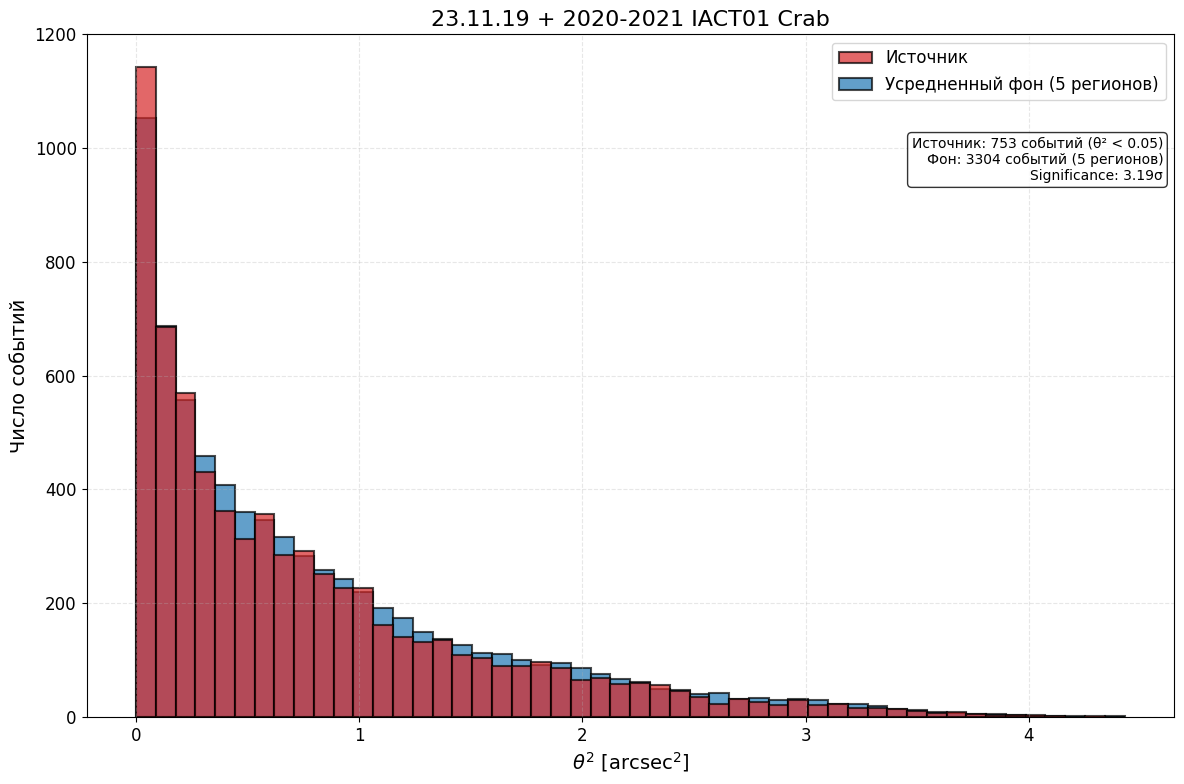

In [9]:
def plot_combined_with_averaged_background(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, bins=40, theta_cut=None):
    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.rcParams['font.size'] = 12

    # Собираем все фоновые данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna(),
        bg5_df['bg5_theta2'].dropna()
    ]

    # Данные источника
    source_data = source_df['source_theta2'].dropna()

    # Параметры гистограмм
    hist_kwargs = {
        'alpha': 0.7,
        'linewidth': 1.5,
        'edgecolor': 'k'
    }

    # Общие бины для всех гистограмм
    bin_edges = np.linspace(0, max(source_data.max(), max(bg.max() for bg in background_dfs)), bins+1)
    
    # Гистограмма источника (для визуализации)
    source_hist, _ = np.histogram(source_data, bins=bin_edges)
    
    # Усредненная гистограмма фона (только для визуализации)
    background_hists = [np.histogram(bg, bins=bin_edges)[0] for bg in background_dfs]
    background_hist_avg = np.mean(background_hists, axis=0)
    print(background_hist_avg)

    # Визуализация
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.bar(bin_centers, background_hist_avg, width=np.diff(bin_edges), 
            color='#1f77b4', label='Усредненный фон (5 регионов)', **hist_kwargs)
    plt.hist(source_data, bins=bin_edges, color='#d62728', label='Источник', **hist_kwargs)

    ### Исправленный расчет значимости ###
    N_on = np.sum(source_data < theta_cut)
    
    # Суммируем все фоновые события до усреднения!
    N_off_total = sum(np.sum(bg < theta_cut) for bg in background_dfs)
    alpha = 1/5 
    
    # Формула Ли-Ма 
    term1 = N_on * np.log((1 + alpha)/alpha * (N_on/(N_on + N_off_total)))
    term2 = N_off_total * np.log((1 + alpha) * (N_off_total/(N_on + N_off_total)))
    S = np.sqrt(2 * (term1 + term2)) 
    S = round(S, 2)

    # Добавляем статистику
    stats_text = "\n".join([
        f"Источник: {N_on} событий (θ² < {theta_cut})",
        f"Фон: {N_off_total} событий (5 регионов)",
        f"Significance: {S}σ"
    ])

    plt.annotate(stats_text, xy=(0.99, 0.85), xycoords='axes fraction',
                ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel(r'$\theta^2$ [arcsec$^2$]', fontsize=14)
    plt.ylabel('Число событий', fontsize=14)
    plt.title('23.11.19 + 2020-2021 IACT01 Crab', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    # plt.yscale('log')
    plt.tight_layout()
    plt.savefig('teta_231119_2020-2021_IACT01.png', dpi=300, bbox_inches='tight')
    plt.show()

# Вызов функции для построения графика
plot_combined_with_averaged_background(
    source_processed,
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed,
    bins=50,
    theta_cut=0.05 
)

In [10]:
exp_data = source_processed[source_processed.source_theta2<0.05]

## Эффективная площадь

### Моделирование

In [11]:
# с хилласом (триггер телескопа)
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_hillas_iact01_14_7fix_cb0.csv' # 607
# file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv' # 599
sim_hill_599 = pd.read_csv(file_simulation)
# изначальное моделирование
# file_sim = '/home/alexandra/Desktop/TAIGA/taiga599_A_sums2' # 599
file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_A_sums2' # 607
sim_all_599 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_599 = sim_all_599.iloc[::5]

sim_all_599

,A,xtet,ytet,dist,AI,N_b_f,col7,col8,col9,col10,E_sim
0,16405.700524,-3.51,-763.423000,862.035344,861.425281,538.202012,9,-8.216540e-07,4.003812e-09,3988.9120,192.90130
5,99345.490067,-3.51,-376.804531,481.325557,478.704834,3249.551753,1762,-1.849006e-06,9.340619e-09,24233.1600,192.90130
10,16602.984388,-3.51,-274.113594,382.203147,378.244031,514.804448,24,-2.093036e-06,1.071607e-08,3939.2420,192.90130
15,36477.925585,-3.51,937.214687,853.299715,846.123549,1230.009771,181,-4.628191e-06,9.035946e-09,9248.8720,192.90130
20,134610.921699,-3.51,268.256000,209.437465,193.660328,4397.469199,2436,-3.155656e-06,7.770400e-09,33430.2700,192.90130
...,...,...,...,...,...,...,...,...,...,...,...
122825,4632.888063,-3.51,-895.017875,992.661497,989.501456,149.210284,5,2.184235e-07,3.062435e-09,1253.6390,50.57771
122830,41305.903035,-3.51,-268.577625,376.913837,370.628434,1387.896816,692,-1.004076e-06,6.373720e-09,9994.6690,50.57771
122835,3492.974604,-3.51,1004.395125,919.940902,918.738887,127.253657,3,-3.246958e-06,1.418263e-08,914.3088,50.57771
122840,33223.837840,-3.51,225.168141,174.560666,163.853984,1110.130991,498,-1.903956e-06,7.244702e-09,8422.3290,50.57771


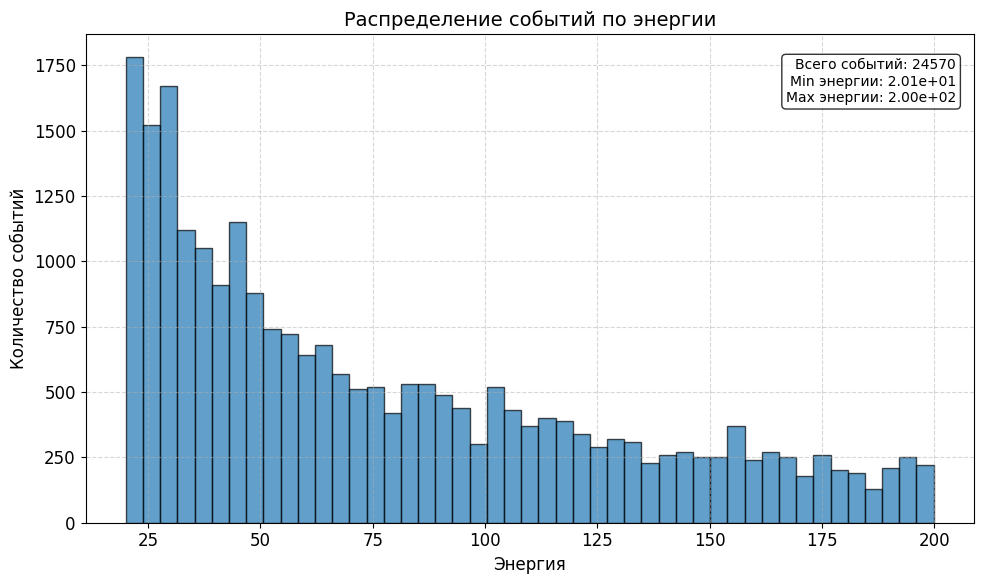

In [12]:
# проверка диапазона по энергии
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_all_599['E_sim'].min()
energy_max = sim_all_599['E_sim'].max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_all_599['E_sim'], bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_all_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

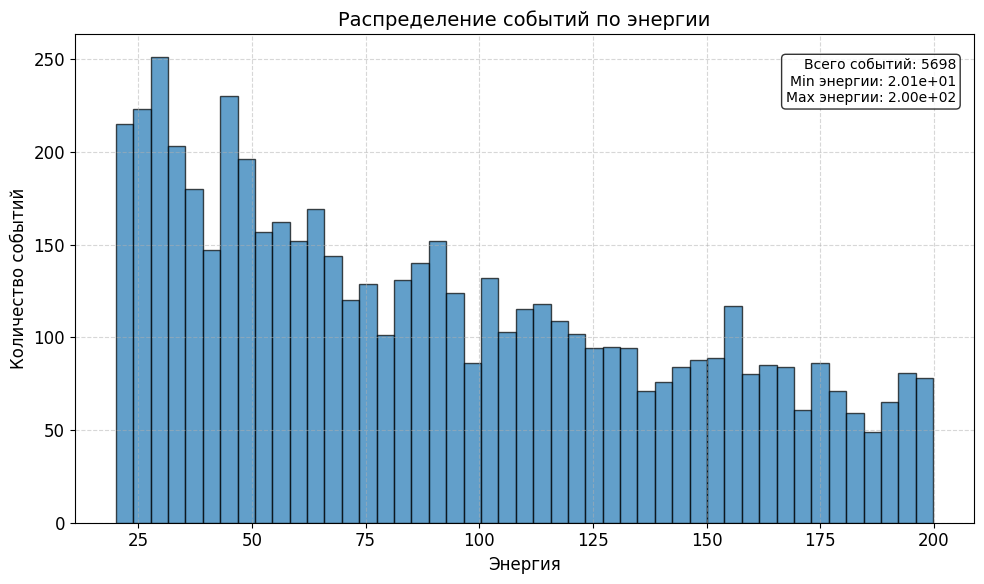

In [13]:
# проверка диапазона по энергии из телескопа
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_hill_599.energy.min()
energy_max = sim_hill_599.energy.max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_hill_599.energy, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_hill_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [14]:
def filter_hillas_data(df):
    common_filters = (
        (df['size'] > 120) &
        (df['width[0]'] > 0.024) &
        (df['width[0]'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length[0]'] < 0.145 * np.log10(df['size']))
    )
    
    source_df = df[
        common_filters &
        (df['dist[0]'].between(0.36, 1.44))
    ]
    
    return source_df

sim_hill_selected_599 = filter_hillas_data(sim_hill_599)
sim_hill_selected_599

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
15,15,7,8,9,21.8716,564.941,-0.281732,1.364420,0.592062,0.339816,...,0.862741,-169.4440,-95.0479,0.611931,5.68603,0.596712,-0.570947,380.734,1,1.0
17,17,9,6,14,21.1437,1197.680,1.097350,0.628994,0.709341,0.237514,...,0.862687,29.2022,14.2484,0.653973,6.05108,0.638768,-0.207357,455.599,1,1.0
18,18,10,0,34,110.3450,6887.600,0.370652,0.058827,0.662588,0.486149,...,0.862740,104.6000,-12.1880,0.597300,6.64991,0.582076,0.393503,430.012,1,1.0
44,44,21,9,9,26.1397,595.995,0.456772,-0.202947,0.443302,0.392418,...,0.862748,187.8000,-105.5590,0.609325,6.06260,0.594105,-0.194277,349.541,1,1.0
87,87,42,1,9,26.9672,674.333,-0.249500,0.449264,0.546384,0.376761,...,0.862743,185.4600,-35.3750,0.627825,7.20766,0.612611,0.950113,371.183,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,5649,2443,5,15,35.8983,1800.840,0.284027,0.963435,0.727695,0.331113,...,0.862790,20.8837,-47.8640,0.576863,6.87313,0.561631,0.617553,385.210,1,1.0
5669,5669,2448,4,40,145.5070,8679.110,-0.163476,0.340007,0.455649,0.558650,...,0.862822,90.1131,-90.7903,0.544348,6.50191,0.529103,0.247803,425.292,1,1.0
5675,5675,2450,8,33,151.0520,7736.760,1.392090,0.003370,0.670568,0.431882,...,0.862759,131.7170,56.9364,0.613315,6.25797,0.598096,0.000953,400.854,1,1.0
5679,5679,2452,6,8,21.9253,620.102,0.611821,0.369915,0.810878,0.290046,...,0.862686,88.1806,-22.4107,0.654194,6.36969,0.638989,0.111253,338.686,1,1.0


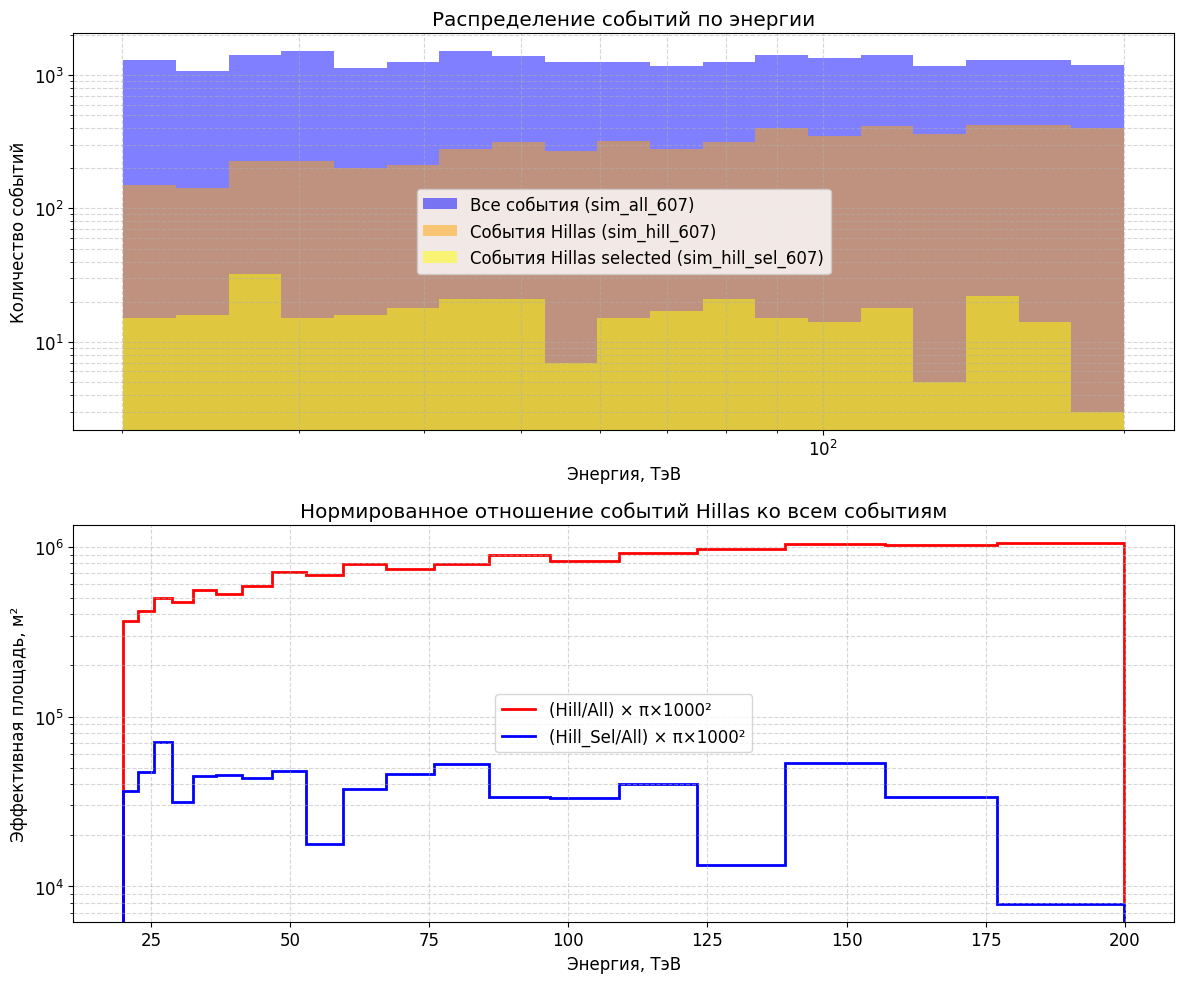

In [15]:
df_all = sim_all_599 
df_hill = sim_hill_599 
df_hill_sel = sim_hill_selected_599

# Определение диапазона энергий (логарифмические бины)
energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)  # 20 логарифмических бинов

# Расчет гистограмм
hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
hist_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges)
hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges)


# Отношение (Hill/All) * площадь круга (R=1000 м)
area_circle = np.pi * 1000**2
ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle

# Построение графиков
plt.figure(figsize=(12, 10))

# 1. Распределения по энергии
plt.subplot(2, 1, 1)
plt.stairs(hist_all, bin_edges, label='Все события (sim_all_607)', fill=True, alpha=0.5, color='blue')
plt.stairs(hist_hill, bin_edges, label='События Hillas (sim_hill_607)', fill=True, alpha=0.5, color='orange')
plt.stairs(hist_hill_sel, bin_edges, label='События Hillas selected (sim_hill_sel_607)', fill=True, alpha=0.5, color='yellow')
plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Количество событий')
plt.title('Распределение событий по энергии')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# 2. Отношение 
plt.subplot(2, 1, 2)
plt.stairs(ratio, bin_edges, label='(Hill/All) × π×1000²', color='red', linewidth=2)
plt.stairs(ratio_sel, bin_edges, label='(Hill_Sel/All) × π×1000²', color='blue', linewidth=2)
# plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Эффективная площадь, м²')
plt.title('Нормированное отношение событий Hillas ко всем событиям')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eff_sq_all_607.png', dpi=300, bbox_inches='tight')
plt.show()

### Реконструкция по энергии

### Cчитываем данные моделирования

In [16]:
# с хилласом (триггер телескопа)
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_hillas_iact01_14_7fix_cb0.csv' # 607
sim_hill_607 = pd.read_csv(file_simulation)
# изначальное моделирование
file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_A_sums2' # 607
sim_all_607 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_607 = sim_all_607.iloc[::5] # для первого телескопа каждый пятый берем (всего 5)

sim_all_607

,A,xtet,ytet,dist,AI,N_b_f,col7,col8,col9,col10,E_sim
0,16405.700524,-3.51,-763.423000,862.035344,861.425281,538.202012,9,-8.216540e-07,4.003812e-09,3988.9120,192.90130
5,99345.490067,-3.51,-376.804531,481.325557,478.704834,3249.551753,1762,-1.849006e-06,9.340619e-09,24233.1600,192.90130
10,16602.984388,-3.51,-274.113594,382.203147,378.244031,514.804448,24,-2.093036e-06,1.071607e-08,3939.2420,192.90130
15,36477.925585,-3.51,937.214687,853.299715,846.123549,1230.009771,181,-4.628191e-06,9.035946e-09,9248.8720,192.90130
20,134610.921699,-3.51,268.256000,209.437465,193.660328,4397.469199,2436,-3.155656e-06,7.770400e-09,33430.2700,192.90130
...,...,...,...,...,...,...,...,...,...,...,...
122825,4632.888063,-3.51,-895.017875,992.661497,989.501456,149.210284,5,2.184235e-07,3.062435e-09,1253.6390,50.57771
122830,41305.903035,-3.51,-268.577625,376.913837,370.628434,1387.896816,692,-1.004076e-06,6.373720e-09,9994.6690,50.57771
122835,3492.974604,-3.51,1004.395125,919.940902,918.738887,127.253657,3,-3.246958e-06,1.418263e-08,914.3088,50.57771
122840,33223.837840,-3.51,225.168141,174.560666,163.853984,1110.130991,498,-1.903956e-06,7.244702e-09,8422.3290,50.57771


### Отбираем данные (каты Хилласа)

In [17]:
def filter_data(df):
    common_filters = (
        (df['size'] > 120) &
        (df['width[0]'] > 0.024) &
        (df['width[0]'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length[0]'] < 0.145 * np.log10(df['size']))
    )
    
    source_df = df[
        common_filters &
        (df['dist[0]'].between(0.36, 1.44))
    ]
    return source_df

sim_hill_607_sel = filter_data(sim_hill_607)
sim_hill_607_sel

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
15,15,7,8,9,21.8716,564.941,-0.281732,1.364420,0.592062,0.339816,...,0.862741,-169.4440,-95.0479,0.611931,5.68603,0.596712,-0.570947,380.734,1,1.0
17,17,9,6,14,21.1437,1197.680,1.097350,0.628994,0.709341,0.237514,...,0.862687,29.2022,14.2484,0.653973,6.05108,0.638768,-0.207357,455.599,1,1.0
18,18,10,0,34,110.3450,6887.600,0.370652,0.058827,0.662588,0.486149,...,0.862740,104.6000,-12.1880,0.597300,6.64991,0.582076,0.393503,430.012,1,1.0
44,44,21,9,9,26.1397,595.995,0.456772,-0.202947,0.443302,0.392418,...,0.862748,187.8000,-105.5590,0.609325,6.06260,0.594105,-0.194277,349.541,1,1.0
87,87,42,1,9,26.9672,674.333,-0.249500,0.449264,0.546384,0.376761,...,0.862743,185.4600,-35.3750,0.627825,7.20766,0.612611,0.950113,371.183,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,5649,2443,5,15,35.8983,1800.840,0.284027,0.963435,0.727695,0.331113,...,0.862790,20.8837,-47.8640,0.576863,6.87313,0.561631,0.617553,385.210,1,1.0
5669,5669,2448,4,40,145.5070,8679.110,-0.163476,0.340007,0.455649,0.558650,...,0.862822,90.1131,-90.7903,0.544348,6.50191,0.529103,0.247803,425.292,1,1.0
5675,5675,2450,8,33,151.0520,7736.760,1.392090,0.003370,0.670568,0.431882,...,0.862759,131.7170,56.9364,0.613315,6.25797,0.598096,0.000953,400.854,1,1.0
5679,5679,2452,6,8,21.9253,620.102,0.611821,0.369915,0.810878,0.290046,...,0.862686,88.1806,-22.4107,0.654194,6.36969,0.638989,0.111253,338.686,1,1.0


### Восстанавливаем энергию по моделированию: получаем коэфф a и b

305
Средняя ошибка реконструкции: 24.75%


/tmp/ipykernel_4266/2311393989.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sim_hill_607_sel['dist_group'] = pd.cut(sim_hill_607_sel['dist[0]'], bins=bins)
/tmp/ipykernel_4266/2311393989.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sim_hill_607_sel['reconstructed_energy'] = sim_hill_607_sel.apply(reconstruct_energy, axis=1)


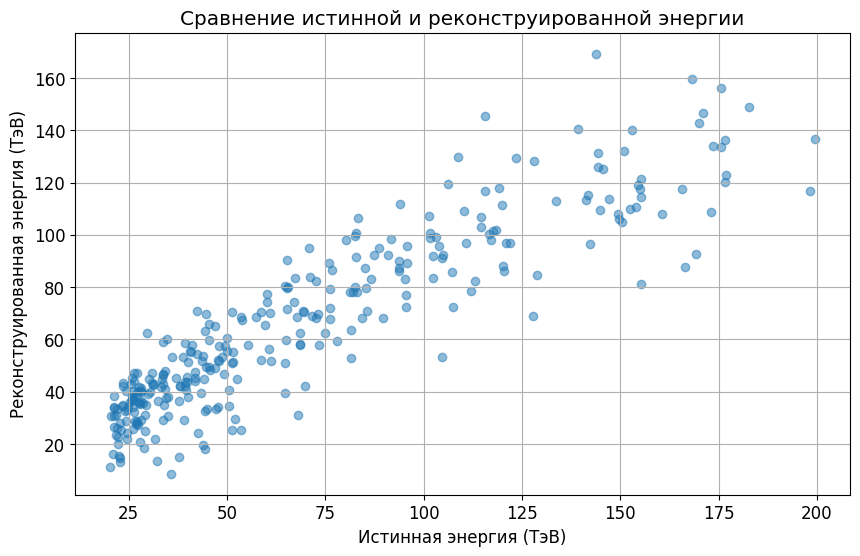

,event_number,energy,size,dist[0],dist_group,reconstructed_energy
15,7,21.8716,564.941,1.393210,"(1.08, 1.44]",23.361454
17,9,21.1437,1197.680,1.264840,"(1.08, 1.44]",38.430722
18,10,110.3450,6887.600,0.375292,"(0.36, 0.72]",109.098278
44,21,26.1397,595.995,0.499828,"(0.36, 0.72]",25.608756
87,42,26.9672,674.333,0.513896,"(0.36, 0.72]",27.551831
108,50,47.1612,928.006,0.365688,"(0.36, 0.72]",33.287239
117,53,83.2908,6625.150,0.707505,"(0.36, 0.72]",106.616837
150,69,22.2082,354.221,0.809655,"(0.72, 1.08]",19.885425
156,72,24.4738,512.084,1.128100,"(1.08, 1.44]",21.889659
201,95,120.5090,4040.580,1.432900,"(1.08, 1.44]",86.003133


In [18]:
# Разбиваем с шагом 0.36°
step = 0.36
min_val, max_val = 0.36, 1.44  

bins = np.arange(min_val, max_val + step, step)

sim_hill_607_sel['dist_group'] = pd.cut(sim_hill_607_sel['dist[0]'], bins=bins)

# Функция для фитирования
def energy_fit(x, a, b):
    return a + b * np.log10(x)

# Вычисление коэффициентов для каждой группы
coefficients = {}
for group in sim_hill_607_sel['dist_group'].unique():
    group_data = sim_hill_607_sel[sim_hill_607_sel['dist_group'] == group]
    popt, _ = curve_fit(energy_fit, group_data['size'], np.log10(group_data['energy']))
    coefficients[group] = {'a': popt[0], 'b': popt[1]}

# Восстановление энергии
def reconstruct_energy(row):
    coeff = coefficients[row['dist_group']]
    return 10**(coeff['a'] + coeff['b'] * np.log10(row['size']))

sim_hill_607_sel['reconstructed_energy'] = sim_hill_607_sel.apply(reconstruct_energy, axis=1)

# Проверка точности реконструкции 
valid_events = sim_hill_607_sel.dropna(subset=['reconstructed_energy', 'energy'])
reconstruction_error = np.abs(valid_events['reconstructed_energy'] - valid_events['energy']) / valid_events['energy']
print(len(reconstruction_error))
print(f"Средняя ошибка реконструкции: {np.mean(reconstruction_error)*100:.2f}%")

plt.figure(figsize=(10, 6))
plt.scatter(valid_events['energy'], valid_events['reconstructed_energy'], alpha=0.5)
plt.xlabel('Истинная энергия (ТэВ)')
plt.ylabel('Реконструированная энергия (ТэВ)')
plt.title('Сравнение истинной и реконструированной энергии')
plt.grid(True)
plt.show()

sim_hill_607_sel[['event_number', 'energy', 'size', 'dist[0]', 'dist_group', 'reconstructed_energy']].head(10)

### Восстанавливаем энергию в экспериментальных данных

/tmp/ipykernel_4266/2308681255.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_data['dist_group'] = pd.cut(exp_data['dist1'], bins=bins)
/tmp/ipykernel_4266/2308681255.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_data['reconstructed_energy'] = exp_data.apply(reconstruct_exp_energy, axis=1)


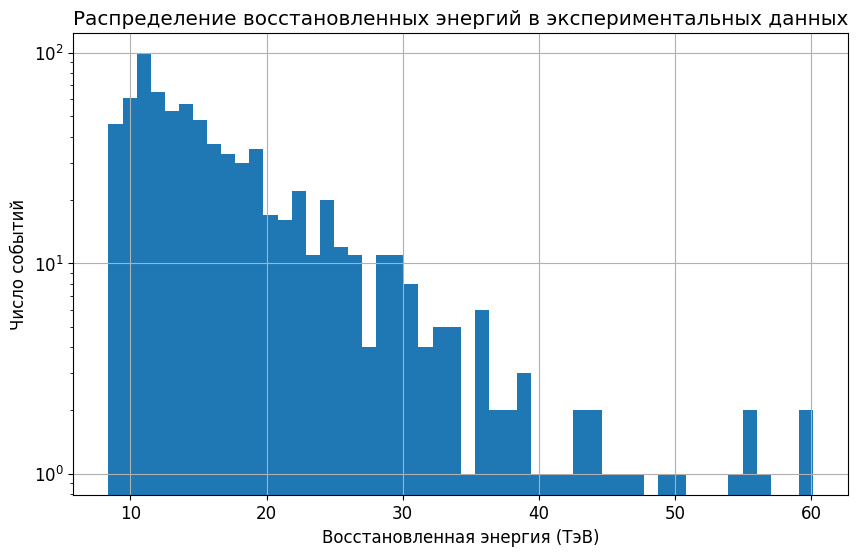

In [19]:
# Разбиваем экспериментальные данные на те же группы dist
exp_data['dist_group'] = pd.cut(exp_data['dist1'], bins=bins)

# Восстановление энергии с использованием ранее найденных коэффициентов
def reconstruct_exp_energy(row):
    coeff = coefficients[row['dist_group']]
    return 10**(coeff['a'] + coeff['b'] * np.log10(row['size']))

exp_data['reconstructed_energy'] = exp_data.apply(reconstruct_exp_energy, axis=1)

# Фильтрация и анализ результатов
valid_exp_events = exp_data.dropna(subset=['reconstructed_energy'])
# print(f"Успешно восстановлено энергий: {len(valid_exp_events)}/{len(exp_data)}")

# Визуализация распределения восстановленных энергий
plt.figure(figsize=(10, 6))
plt.hist(valid_exp_events['reconstructed_energy'], bins=50, log=True)
plt.xlabel('Восстановленная энергия (ТэВ)')
plt.ylabel('Число событий')
plt.title('Распределение восстановленных энергий в экспериментальных данных')
plt.grid(True)
plt.show()

### Строим спектр: без анфолдинга пока

In [38]:
# оценка времени
def estimate_observation_time(exp_data):
    """
    Оценка времени наблюдений:
    - Сортируем по минимальному unix_time_ns каждой порции.
    - Считаем уникальные интервалы по 2 минуты, не перекрываясь.
    """
    # Получаем минимальные времена на каждую порцию
    min_times = exp_data.groupby('por')['unix_time_ns'].min().sort_values().values

    portion_duration_ns = 2 * 60 * 1_000_000_000  # 2 минуты в наносекундах
    count = 0
    current_end = 0

    for t in min_times:
        if t > current_end:
            count += 1
            current_end = t + portion_duration_ns

    total_seconds = count * 2 * 60
    return total_seconds

time = estimate_observation_time(hillas)
time/3600

5.2

In [37]:
hillas

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49


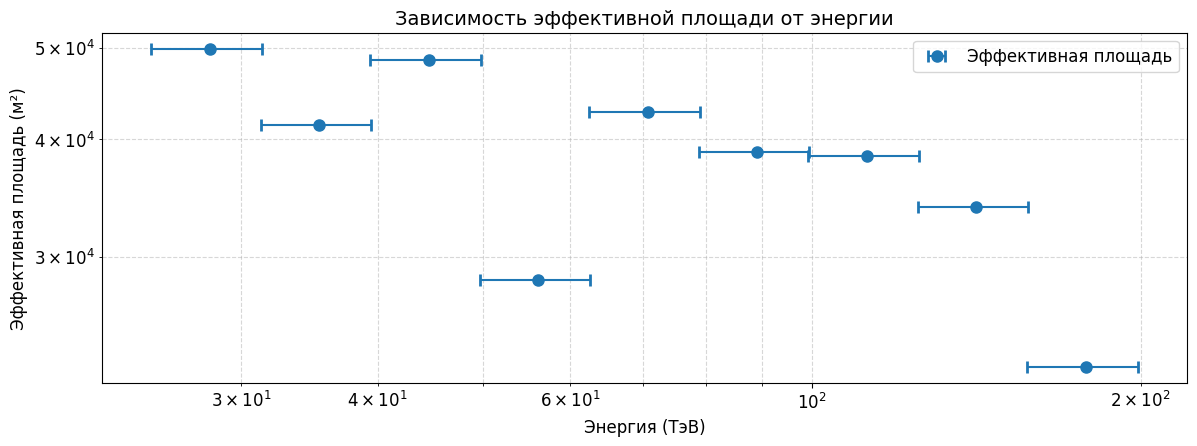

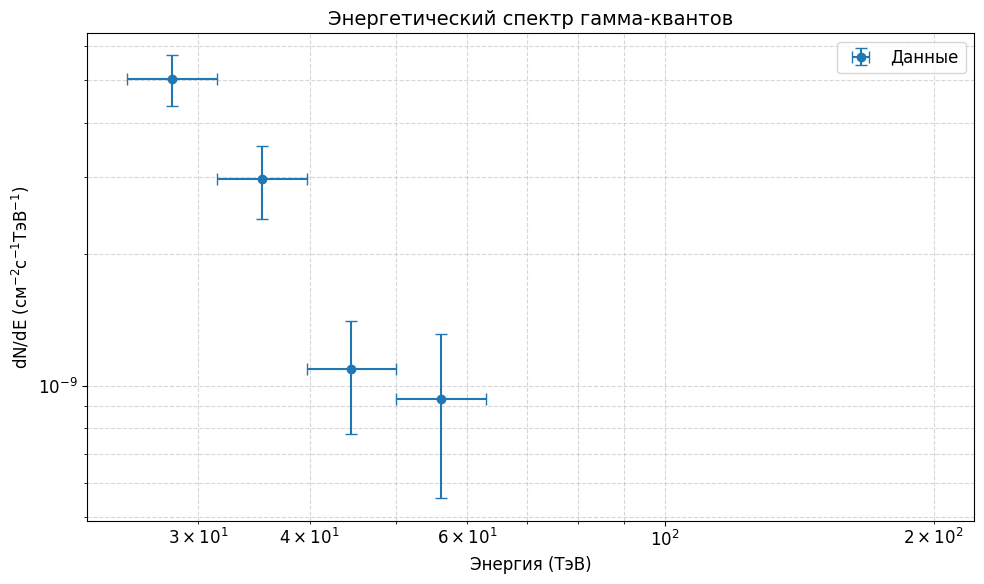

In [36]:
from scipy.stats import binned_statistic

# Эффект площадь
def calculate_effective_area(df_selected, df_all, energy_bins, R=1000):

    # Гистограммы для выбранных и всех событий
    hist_sel, _ = np.histogram(df_selected['energy'], bins=energy_bins)
    hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=energy_bins)
    
    area_circle = np.pi * R**2
    effective_area = (hist_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
    
    return bin_edges, effective_area

# Определение энергетических бинов
energy_bins = np.logspace(np.log10(25), np.log10(200), 10)  # от 25 до 200 ТэВ

# Расчет эффективной площади
bin_edges, eff_area = calculate_effective_area(
    df_hill_sel, # взяла соб-ия из моделирования после триггера телескопа с адронным подавлением
    df_all,  
    energy_bins
)

# Отрисовка эфф площади: для проверки
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # геометрические центры бинов
bin_widths = bin_edges[1:] - bin_edges[:-1]  # ширина бинов

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plt.errorbar(bin_centers, eff_area, 
            xerr=bin_widths/2,
            fmt='o', markersize=8, 
            capsize=4, capthick=2,
            label='Эффективная площадь')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Энергия (ТэВ)', fontsize=12)
plt.ylabel('Эффективная площадь (м²)', fontsize=12)
plt.title('Зависимость эффективной площади от энергии', fontsize=14)
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.legend()

# Расчет диффер потока
def calculate_spectrum(data, energy_bins, eff_area):
    # Число событий в бинах
    counts, bin_edges = np.histogram(data['reconstructed_energy'], bins=energy_bins)
    
    # Центры бинов
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    
    # Ширина бинов в лог шкале
    d_logE = np.diff(np.log10(bin_edges))
    
    # Дифференциальный поток (dN/dE)
    # flux = counts / (eff_area * observation_time * (10**d_logE * bin_centers))  # ширина энергетического бина (10**d_logE), центральная энергия бина (bin_centers)
    flux = counts / (eff_area * observation_time * 10**d_logE)  # ширина энергетического бина (10**d_logE)

    # Ошибки
    flux_errors = np.sqrt(counts) / (eff_area * observation_time * 10**d_logE)
    
    return bin_edges, flux, flux_errors

# Время наблюдения
observation_time = 50 * 3600 # надо бы норм рассчитать

# Расчет спектра
bin_edges, flux, flux_errors = calculate_spectrum(exp_data, energy_bins, eff_area)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

# Построение спектра
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, flux, 
            xerr=[bin_centers - bin_edges[:-1], bin_edges[1:] - bin_centers],
            yerr=flux_errors,
            fmt='o', capsize=4, label='Данные')

# Добавление спектра Краба
# E_plot = np.logspace(np.log10(25), np.log10(200), 100)
# plt.plot(E_plot, 3e-11 * (E_plot)**(-2.6), 'r--', 
#          label='Спектр Краба (E$^{-2.6}$)')

# Настройка графика
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Энергия (ТэВ)', fontsize=12)
plt.ylabel('dN/dE (см$^{-2}$с$^{-1}$ТэВ$^{-1}$)', fontsize=12)
plt.title('Энергетический спектр гамма-квантов', fontsize=14)
plt.legend()
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('gamma_energy_spectrum.png', dpi=300)
plt.show()

In [26]:
exp_data.head(10).style

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,CR400phe,CR_portion,median_background,MAD_background,numb_pix,num_islands,size,Xc,Yc,con_selected_island,con2,length,width,dist1,dist2,a_axis,skewness_w,skewness_l,kurtosis_w,kurtosis_l,alpha1,alpha2,tel_ra,tel_dec,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha,source_theta2,dist_group,reconstructed_energy
1916,1,15163,13:39:19:800:552:970,1612791559800552970,0.200000,0.030000,182.756270,60.149000,185.280230,60.143000,0.340000,18.220000,0.140000,3.160000,4,1,216.750000,0.938535,0.498036,1.000000,0.880000,0.184030,0.086186,0.603677,2.277385,-0.903124,2.832617,0.049788,0.294993,1.751316,13.100000,54.800000,84.990000,21.960000,83.630000,22.010000,1.280000,0.000000,1,1,0,0,9.270000,0.930000,2.273750,54.738445,0.679562,21.854510,1.692470,20.942663,2.252281,87.589866,1.634051,58.440902,0.029373,"(0.36, 0.72]",14.068078
3118,2,51108,13:40:46:779:731:920,1612791646779731920,0.220000,0.030000,188.237780,59.945000,185.955200,60.121000,2.250000,14.740000,0.140000,2.970000,4,1,182.000000,-0.346180,0.213271,1.000000,0.830000,0.232156,0.067195,0.919187,1.503948,0.509488,3.585978,0.080173,0.175537,3.667429,1.000000,26.800000,82.390000,21.930000,83.630000,22.010000,-1.160000,-0.220000,0,0,0,0,-1.000000,0.910000,1.506195,26.742324,1.328566,61.134257,1.573018,71.770483,1.163427,23.780446,0.802661,85.082407,0.047716,"(0.72, 1.08]",13.283498
5095,3,79413,13:43:01:405:467:490,1612791781405467490,0.090000,0.030000,189.273400,59.907000,186.996990,60.081000,2.470000,14.630000,0.100000,3.190000,4,1,134.270000,-0.426507,0.433272,1.000000,0.730000,0.274263,0.095719,0.976815,1.596560,0.869039,-0.276637,0.321520,0.076398,7.450664,0.800000,48.800000,82.390000,21.950000,83.630000,22.010000,-1.160000,-0.220000,1,1,0,0,9.230000,0.910000,1.600778,48.648210,1.548304,50.378626,1.787765,88.958076,1.063024,1.131150,0.575467,85.721109,0.004395,"(0.72, 1.08]",11.047913
5202,3,79878,13:43:07:156:729:290,1612791787156729290,0.160000,0.030000,189.318670,59.903000,187.039550,60.080000,2.470000,14.630000,0.100000,3.190000,6,1,198.240000,-0.605026,0.077084,1.000000,0.760000,0.209110,0.105201,0.625641,1.767230,0.343242,-0.731725,0.079312,0.580441,2.995568,9.200000,14.400000,82.390000,21.950000,83.630000,22.010000,-1.160000,-0.220000,1,1,0,0,9.220000,0.910000,1.770803,14.315173,1.211011,81.308510,1.684129,54.181308,1.437167,27.268045,0.834090,82.500175,0.010812,"(0.36, 0.72]",13.343679
6447,4,86551,13:44:39:657:015:610,1612791879657015610,0.160000,0.030000,190.028850,59.869000,187.754600,60.049000,2.380000,12.710000,0.110000,3.210000,6,1,307.650000,-2.092584,-0.181339,1.000000,0.740000,0.260755,0.112821,0.938114,3.272868,0.011682,0.317106,0.079972,0.268486,6.032339,3.100000,6.400000,82.390000,21.950000,83.630000,22.010000,-1.160000,-0.220000,1,1,0,0,9.100000,0.910000,3.277251,6.364919,1.942045,29.390654,2.950614,14.657939,2.800008,26.900593,1.704541,38.470371,0.003416,"(0.72, 1.08]",18.257632
7461,4,92608,13:45:54:503:312:230,1612791954503312230,0.000000,0.030000,190.607390,59.836000,188.333480,60.022000,2.380000,12.710000,0.110000,3.210000,9,1,527.050000,-1.771533,0.861395,1.000000,0.500000,0.379061,0.124473,1.250935,2.995824,-1.992411,-0.136763,0.346528,0.416108,32.300924,2.800000,51.100000,82.390000,21.950000,83.630000,22.010000,-1.160000,-0.230000,1,1,0,0,9.060000,0.900000,2.998757,51.193005,2.420413,8.417888,3.093883,28.879405,2.167778,70.188206,0.992748,64.975165,0.012535,"(1.08, 1.44]",22.311383
8157,5,96572,13:46:55:119:186:860,1612792015119186860,0.120000,0.030000,191.072590,59.810000,188.799820,59.999000,2.290000,13.420000,0.100000,3.200000,5,1,157.390000,-1.365140,0.933031,1.000000,0.610000,0.304758,0.101985,1.181928,2.617768,-4.420097,0.030894,0.005330,0.143704,9.913668,2.600000,61.700000,82.390000,21.960000,83.630000,22.010000,-1.160000,-0.2300

In [ ]:
from matplotlib.colors import LogNorm
sim_energy = df['energy']   
reco_energy = df['reconstructed_energy']  
def calculate_response_matrix(sim_energy, reco_energy, energy_bins):
    
    # 1. Построение 2D гистограммы (матрицы отклика)
    R_raw, x_edges, y_edges = np.histogram2d(
        sim_energy, 
        reco_energy, 
        bins=[energy_bins, energy_bins],
    )
    
    # 2. Нормализация по строкам (по истинной энергии)
    row_sums = R_raw.sum(axis=1, keepdims=True)
    R_norm = np.divide(R_raw, row_sums, out=np.zeros_like(R_raw), where=row_sums!=0)
    
    # 3. Вычисление центров бинов
    energy_centers = (energy_bins[:-1] + energy_bins[1:]) / 2
    
    return R_raw, R_norm, energy_centers

def plot_response_matrix(R, energy_centers, title="Матрица отклика"):
    """Визуализация матрицы отклика"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Логарифмическая шкала для цветов
    im = ax.pcolormesh(
        energy_centers, 
        energy_centers, 
        R.T,  # Транспонируем для правильной ориентации
        norm=LogNorm(vmin=1e-3, vmax=1),
        cmap='viridis', 
        shading='auto'
    )
    
    # Добавление значений в ячейки (только для значимых значений)
    for i in range(len(energy_centers)):
        for j in range(len(energy_centers)):
            if R[i, j] > 0.01:  # Показываем только значения > 1%
                ax.text(
                    energy_centers[i], 
                    energy_centers[j], 
                    f'{R[i, j]:.2f}',
                    ha='center', 
                    va='center', 
                    color='white' if R[i, j] > 0.3 else 'black',
                    fontsize=8
                )
    
    plt.colorbar(im, ax=ax, label="Вероятность отклика")
    ax.set_xlabel("Моделируемая энергия, ТэВ")
    ax.set_ylabel("Восстановленная энергия, ТэВ")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)
    plt.show()

# 1. Определение энергетических бинов (логарифмическая шкала)
energy_bins = np.logspace(np.log10(df.reconstructed_energy.min()), np.log10(df.reconstructed_energy.max()), 25)
# 2. Расчет матрицы отклика
R_raw, R_norm, energy_centers = calculate_response_matrix(
    sim_energy=sim_energy,
    reco_energy=reco_energy,
    energy_bins=energy_bins
)

# 3. Визуализация
plot_response_matrix(R_norm, energy_centers, "Нормализованная матрица отклика")

In [ ]:
# суммарно 19 год добавить (после того, как Паша обработает)
# unfolding